# Firm Data Report — A_FirmData.csv

Descriptive statistics and data-quality checks for the German firm-level
panel used in the credit-demand prediction project.

Unit of observation: firm-year. All monetary variables are in **thousands
of EUR**. See `docs/variable_overview.md` for a full explanation of every
variable.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
%matplotlib inline

## Import data

In [25]:
df = pd.read_csv(
    'data/A_FirmData.csv',
    dtype={
        'idnr': 'string', 'name': 'string', 'type': 'string',
        'naics_core_code': 'Int64', 'closdate_year': 'Int64',
    },
    parse_dates=['dateinc'],
    low_memory=False,
)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Loaded 1,745,766 rows, 31 columns


,idnr,name,type,dateinc,naics_core_code,closdate_year,empl,ncliGrowthNextYear,fias,ifas,tfas,ofas,cuas,stok,debt,ocas,cash,toas,shfd,capi,osfd,ncli,ltdb,oncl,prov,culi,loan,cred,ocli,tshf,wkca
0,DE2010000001,WIENER CONDITOREI & CAFFEEHAUS BETRIEBS-GMBH,Limited liability company - GmbH,1977-01-12,3118,2013,NaN,-0.034155,530.422,NaN,NaN,NaN,1458.696,57.911,0.0,1400.786,222.867,1989.119,23.961,25.565,-1.604,1964.646,1671.911,292.736,251.197,0.512,0.0,0.0,0.512,1989.119,57.911
1,DE2010000001,WIENER CONDITOREI & CAFFEEHAUS BETRIEBS-GMBH,Limited liability company - GmbH,1977-01-12,3118,2014,NaN,-0.832512,485.991,0.0,485.991,0.0,1497.556,57.405,0.0,1440.151,251.192,1983.547,85.492,25.565,59.928,1897.543,1630.183,267.360,235.513,0.512,0.0,0.0,0.512,1983.547,57.405
2,DE2010000001,WIENER CONDITOREI & CAFFEEHAUS BETRIEBS-GMBH,Limited liability company - GmbH,1977-01-12,3118,2016,148.0,-0.093514,412.977,0.0,412.977,0.0,1421.060,74.466,0.0,1346.595,127.223,1834.038,406.284,25.565,380.720,1114.867,847.897,266.970,219.838,312.887,0.0,0.0,312.887,1834.038,74.466
3,DE2010000001,WIENER CONDITOREI & CAFFEEHAUS BETRIEBS-GMBH,Limited liability company - GmbH,1977-01-12,3118,2017,111.0,-0.119000,413.854,0.0,413.854,0.0,1416.344,62.750,0.0,1353.594,112.973,1830.199,480.562,25.565,454.998,1010.611,733.479,277.132,232.459,339.025,NaN,NaN,0.430,1830.199,NaN
4,DE2010000001,WIENER CONDITOREI & CAFFEEHAUS BETRIEBS-GMBH,Limited liability company - GmbH,1977-01-12,3118,2018,120.0,0.243604,397.356,0.0,397.356,0.0,1360.977,73.882,0.0,1287.095,75.504,1758.334,525.333,25.565,499.769,890.348,624.662,265.686,226.723,342.652,NaN,NaN,NaN,1758.334,NaN


## 1. Check data structure

Basic shape, dtypes, and missing-value check before doing anything else.

In [26]:
print("Shape:", df.shape)
print("Unique firms:", df['idnr'].nunique())
print("Fiscal years:", df['closdate_year'].min(), "-", df['closdate_year'].max())
dup = df.duplicated(subset=['idnr', 'closdate_year']).sum()
print("Duplicate (idnr, closdate_year) pairs:", dup)

Shape: (1745766, 31)
Unique firms: 285321
Fiscal years: 2010 - 2023
Duplicate (idnr, closdate_year) pairs: 0


In [27]:
# Does the data contain any missing values?
df.isnull().sum()

idnr                       0
name                       0
type                       0
dateinc               129154
naics_core_code            0
closdate_year              0
empl                  675872
ncliGrowthNextYear         0
fias                     160
ifas                   60594
tfas                   60643
ofas                   60727
cuas                      37
stok                   29157
debt                   29124
ocas                   12296
cash                   63218
toas                       0
shfd                       0
capi                   39314
osfd                   39314
ncli                       0
ltdb                       0
oncl                       0
prov                     114
culi                      60
loan                  659154
cred                  665601
ocli                  512538
tshf                       0
wkca                  680906
dtype: int64

## 2. Variable schema & missingness

See `docs/variable_overview.md` for plain-language definitions of every
column. Table below: missingness and cardinality per variable.

In [28]:
schema = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': (100 * df.isna().mean()).round(2),
    'n_unique': df.nunique(),
}).sort_values('missing_pct', ascending=False)
schema

,dtype,missing_n,missing_pct,n_unique
wkca,float64,680906,39.00,654477
empl,float64,675872,38.71,3267
cred,float64,665601,38.13,209314
loan,float64,659154,37.76,129236
ocli,float64,512538,29.36,867751
dateinc,datetime64[us],129154,7.40,22065
cash,float64,63218,3.62,1029271
ofas,float64,60727,3.48,250812
tfas,float64,60643,3.47,1059919
ifas,float64,60594,3.47,255358


## 3. Panel structure

How many firms are observed each year, and how many years does a typical
firm appear for.

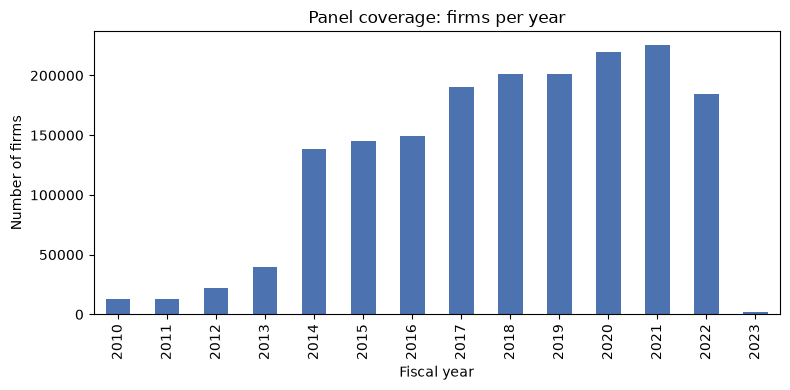

In [29]:
per_year = df.groupby('closdate_year')['idnr'].nunique()

fig, ax = plt.subplots(figsize=(8, 4))
per_year.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Fiscal year')
ax.set_ylabel('Number of firms')
ax.set_title('Panel coverage: firms per year')
plt.tight_layout()
plt.show()

In [30]:
obs_per_firm = df.groupby('idnr').size()
print(f"Firm-years per firm — mean: {obs_per_firm.mean():.2f}, "
      f"median: {obs_per_firm.median():.0f}, max: {obs_per_firm.max():.0f}")

Firm-years per firm — mean: 6.12, median: 7, max: 9


## 4. Firm characteristics

In [31]:
df['type'].value_counts().to_frame('n_firm_years')

,n_firm_years
type,
Limited liability company - GmbH,1340466
Limited liability company & partnership - GmbH & Co. KG,349406
Registered cooperative - eG,22952
Public limited company - AG,22800
Entrepreneurial company (limited liability) - UG,2767
Entrepreneurial company (limited liability) & partnership - UG & Co. KG,2377
Limited partnership - KG,949
European company - SE,927
General partnership - OHG,655


In [32]:
df['naics_core_code'].value_counts().head(15).to_frame('n_firm_years')

,n_firm_years
naics_core_code,
2382,75896
5311,62344
5511,60723
5413,54818
5415,48829
5614,47426
2361,45763
4231,40326
5312,38241


In [33]:
print(f"Employees available for {df['empl'].notna().sum():,} / {len(df):,} "
      f"firm-years ({100 * df['empl'].notna().mean():.1f}%)")
df['empl'].describe()

Employees available for 1,069,894 / 1,745,766 firm-years (61.3%)


count    1.069894e+06
mean     6.392065e+01
std      3.067909e+02
min      1.000000e+00
25%      1.200000e+01
50%      2.400000e+01
75%      5.100000e+01
max      9.033500e+04
Name: empl, dtype: float64

## 5. Balance-sheet variables — descriptive statistics

All figures in thousands of EUR.

In [34]:
monetary_cols = [
    'fias', 'ifas', 'tfas', 'ofas', 'cuas', 'stok', 'debt', 'ocas', 'cash',
    'toas', 'shfd', 'capi', 'osfd', 'ncli', 'ltdb', 'oncl', 'prov', 'culi',
    'loan', 'cred', 'ocli', 'tshf', 'wkca',
]
df[monetary_cols].describe(percentiles=[.01, .25, .5, .75, .99]).T.round(1)

,count,mean,std,min,1%,25%,50%,75%,99%,max
fias,1745606.0,1.052279e+09,1.299121e+11,-4.310680e+05,0.0,104.2,539.9,250760.5,104110117.4,4.800440e+13
ifas,1685172.0,2.857731e+07,8.750100e+09,-1.643405e+06,0.0,0.0,0.6,25.1,1438466.6,6.677931e+12
tfas,1685123.0,2.131121e+08,2.373662e+10,-1.619740e+08,0.0,72.9,378.4,73286.5,65948298.4,1.187476e+13
ofas,1685039.0,1.259756e+09,2.647672e+11,-2.070230e+05,0.0,0.0,0.0,50.0,34441417.7,2.009250e+14
cuas,1745729.0,2.088321e+09,8.837387e+11,-2.343994e+06,41.6,562.8,1455.2,1086442.0,58311230.3,6.666670e+14
stok,1716609.0,5.812929e+07,8.703745e+09,-2.556060e+08,0.0,0.0,118.6,1307.2,14488736.8,8.518021e+12
debt,1716642.0,6.247700e+07,7.818031e+09,0.000000e+00,0.0,0.0,0.0,0.0,9709602.6,3.382000e+12
ocas,1733470.0,1.983536e+09,8.865047e+11,-6.993126e+06,12.1,379.7,991.7,637221.0,37824433.6,6.666670e+14
cash,1682548.0,7.046036e+07,1.812377e+10,-1.217276e+08,0.2,89.9,394.3,59304.8,12294501.1,1.923938e+13
toas,1745766.0,3.540100e+09,1.105032e+12,-7.755409e+06,125.6,917.9,2388.7,3801199.8,158102421.4,7.866266e+14


In [35]:
# Sanity check: negative values in items that should normally be >= 0
nonneg_expected = ['fias', 'cuas', 'toas', 'tshf', 'culi', 'ncli']
for c in nonneg_expected:
    n_neg = (df[c] < 0).sum()
    flag = "⚠️" if n_neg else "✅"
    print(f"{flag} {c}: {n_neg} negative values")

⚠️ fias: 15 negative values
⚠️ cuas: 24 negative values
⚠️ toas: 183 negative values
⚠️ tshf: 191 negative values
⚠️ culi: 58 negative values
⚠️ ncli: 25 negative values


## 6. Outcome variable: `ncliGrowthNextYear`

One-year-ahead growth in non-current liabilities — the proxy for
firm-level credit demand.

In [36]:
y = df['ncliGrowthNextYear'].dropna()
print(f"Non-missing: {len(y):,} / {len(df):,} ({100*len(y)/len(df):.1f}%)")
y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

Non-missing: 1,745,766 / 1,745,766 (100.0%)


count    1.745766e+06
mean    -5.700192e-02
std      3.899262e-01
min     -1.000000e+00
1%      -9.701629e-01
5%      -7.993054e-01
25%     -2.517599e-01
50%     -4.182905e-02
75%      1.421707e-01
95%      6.402145e-01
99%      9.076575e-01
max      9.999994e-01
Name: ncliGrowthNextYear, dtype: float64

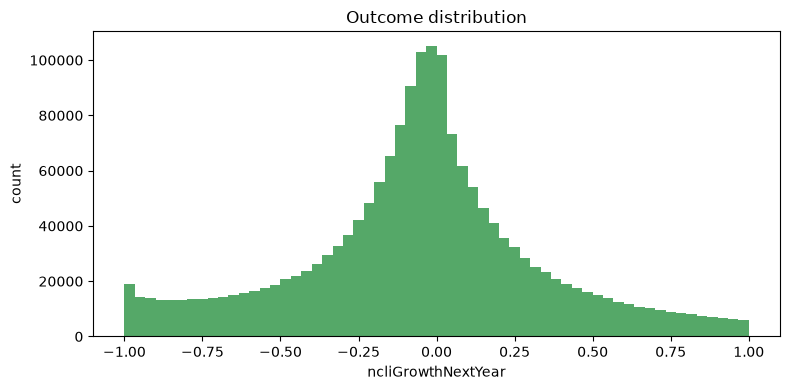

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y, bins=60, color='#55A868')
ax.set_xlabel('ncliGrowthNextYear')
ax.set_ylabel('count')
ax.set_title('Outcome distribution')
plt.tight_layout()
plt.show()

## 7. Outcome by year

Checking for regime shifts (e.g. COVID-19) and whether the out-of-time
train (≤2019) / test (2020–2023) split spans meaningfully different
periods.

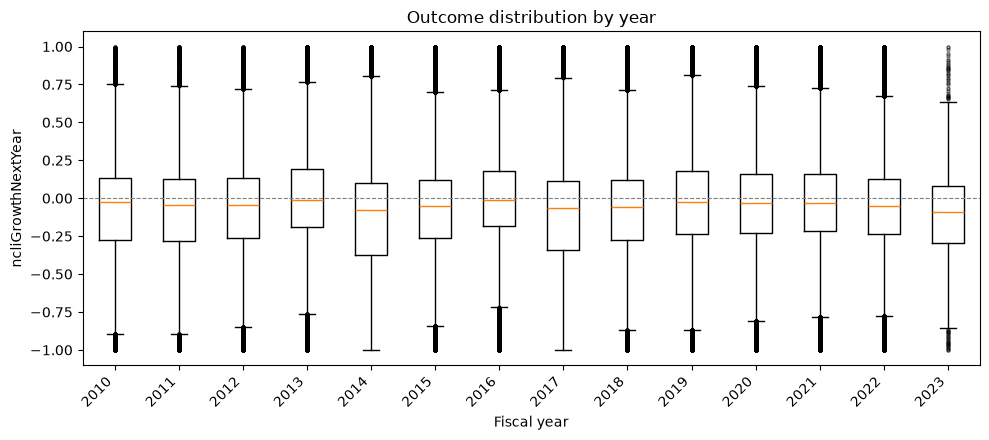

In [38]:
sub = df[['closdate_year', 'ncliGrowthNextYear']].dropna()
years = sorted(sub['closdate_year'].unique())
data_by_year = [sub.loc[sub['closdate_year'] == yr, 'ncliGrowthNextYear'].values for yr in years]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot(data_by_year, tick_labels=[str(yr) for yr in years], showfliers=True,
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Fiscal year')
ax.set_ylabel('ncliGrowthNextYear')
ax.set_title('Outcome distribution by year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
sub.groupby('closdate_year')['ncliGrowthNextYear'].agg(
    n='count', mean='mean', median='median', std='std'
).round(4)

,n,mean,median,std
closdate_year,,,,
2010,13132,-0.0683,-0.0239,0.4194
2011,12950,-0.0729,-0.0416,0.4056
2012,21697,-0.0685,-0.0453,0.3942
2013,39952,-0.0068,-0.0119,0.3945
2014,138425,-0.1294,-0.0754,0.4058
2015,145431,-0.0750,-0.0488,0.3872
2016,149223,-0.0067,-0.0147,0.3693
2017,190256,-0.1094,-0.0651,0.4100
2018,201611,-0.0803,-0.0562,0.3878


## 8. Correlations (selected variables)

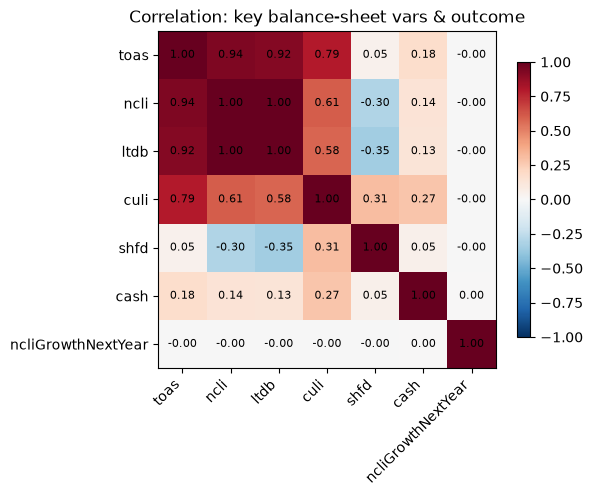

In [40]:
key_vars = ['toas', 'ncli', 'ltdb', 'culi', 'shfd', 'cash', 'ncliGrowthNextYear']
corr = df[key_vars].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(key_vars))); ax.set_xticklabels(key_vars, rotation=45, ha='right')
ax.set_yticks(range(len(key_vars))); ax.set_yticklabels(key_vars)
for i in range(len(key_vars)):
    for j in range(len(key_vars)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation: key balance-sheet vars & outcome')
plt.tight_layout()
plt.show()

---
# Part 2: Variable Overview & Feature Engineering

## 9. Variable overview (plain-language)

A balance sheet answers two questions for one firm on one day (here: the
December fiscal year-end): **what does the firm own** (assets), and **who
has a claim on that value** (liabilities + equity)? These always balance:

```
Assets  =  Liabilities  +  Equity
```

| Group | Variables | Plain-language meaning |
|---|---|---|
| **Identifiers** | `idnr`, `name`, `type`, `dateinc`, `naics_core_code`, `closdate_year`, `empl` | Firm ID, legal form, incorporation date, industry code, fiscal year, employee count |
| **Outcome** | `ncliGrowthNextYear` | One-year-ahead % growth in long-term liabilities — our proxy for credit demand |
| **Fixed assets** | `fias`, `ifas`, `tfas`, `ofas` | Long-term holdings: total, intangible (patents/goodwill), tangible (buildings/machinery), other |
| **Current assets** | `cuas`, `stok`, `debt`, `ocas`, `cash` | Short-term holdings: total, inventory, money owed *to* the firm, other, cash |
| **Equity** | `shfd`, `capi`, `osfd` | Owners' stake: total, paid-in capital, retained earnings |
| **Non-current liabilities** | `ncli`, `ltdb`, `oncl`, `prov` | Long-term debts: total, bank/bond debt, other, provisions |
| **Current liabilities** | `culi`, `loan`, `cred`, `ocli` | Short-term debts: total, short-term loans, money owed *to* suppliers, other |
| **Totals** | `toas`, `tshf`, `wkca` | Total assets, total liabilities+equity (identical to `toas` by construction), working capital |

Full plain-language definitions of every variable: see `docs/variable_overview.md`
in the repo.

**Why no revenue/profit data?** This sample keeps only balance-sheet
variables with good coverage for German EUR-reporting firms — income
statement items were dropped for poor coverage (see
`A_FirmData_description.txt`). We predict credit demand using only
balance-sheet composition, with no direct view of profitability.

## 10. Data quality checks & filtering decisions

Before engineering features, we check for a few specific data problems.
**Philosophy:** filter out only genuine data errors (bad denominators,
broken accounting identities); everything else (missingness, thin early
years, single-year firms) is flagged or handled with lags/indicators
instead of dropped, to avoid silently biasing the sample.

In [41]:
# --- Check 1: non-positive or missing total assets (can't compute ratios) ---
n_bad_toas = ((df['toas'].isna()) | (df['toas'] <= 0)).sum()
print(f"Rows with missing or non-positive toas: {n_bad_toas:,} ({100*n_bad_toas/len(df):.3f}%)")

Rows with missing or non-positive toas: 183 (0.010%)


In [42]:
# --- Check 2: accounting identity (toas should equal tshf) ---
# Allow a small tolerance for rounding (data is in thousands of EUR)
identity_gap = (df['toas'] - df['tshf']).abs()
tolerance = 1.0  # thousands of EUR
n_identity_violation = (identity_gap > tolerance).sum()
print(f"Rows where toas != tshf (tolerance={tolerance}): {n_identity_violation:,} "
      f"({100*n_identity_violation/len(df):.3f}%)")
if n_identity_violation > 0:
    print(identity_gap[identity_gap > tolerance].describe())

Rows where toas != tshf (tolerance=1.0): 301 (0.017%)
count    3.010000e+02
mean     1.130244e+07
std      1.533580e+08
min      1.010000e+00
25%      1.156730e+02
50%      3.000000e+03
75%      6.823570e+05
max      2.654388e+09
dtype: float64


In [43]:
# --- Check 3: firms with only one observed year (can't build lag/momentum features) ---
obs_per_firm = df.groupby('idnr').size()
n_single_year_firms = (obs_per_firm == 1).sum()
print(f"Firms with only 1 observed year: {n_single_year_firms:,} / {df['idnr'].nunique():,} "
      f"({100*n_single_year_firms/df['idnr'].nunique():.1f}%)")
print("Decision: KEEP these rows. Cross-sectional features still apply; "
      "lag-based features will naturally be NaN for these firms' single row.")

Firms with only 1 observed year: 21,358 / 285,321 (7.5%)
Decision: KEEP these rows. Cross-sectional features still apply; lag-based features will naturally be NaN for these firms' single row.


In [44]:
# --- Apply the filter: drop only rows failing checks 1 and 2 ---
n_before = len(df)

mask_valid = (
    df['toas'].notna() & (df['toas'] > 0) &
    ((df['toas'] - df['tshf']).abs() <= tolerance)
)
df_clean = df[mask_valid].copy()

n_after = len(df_clean)
print(f"Rows before filtering: {n_before:,}")
print(f"Rows after filtering:  {n_after:,}")
print(f"Rows dropped:          {n_before - n_after:,} ({100*(n_before-n_after)/n_before:.3f}%)")

Rows before filtering: 1,745,766
Rows after filtering:  1,745,282
Rows dropped:          484 (0.028%)


## 11. Feature engineering

Raw levels (`toas`, `ncli`, ...) mostly reflect firm **size**. The features
below strip size out (ratios), fix skew (logs), and add a time dimension
(lags/momentum) that the raw snapshot doesn't have.

Ratios are **winsorized** at the 1st/99th percentile rather than having
extreme rows dropped, since a single blown-up ratio (from a near-zero
denominator) shouldn't cost us the whole firm-year.

In [45]:
def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)

# --- 11.1 Ratios (scale-free) ---
df_clean['leverage']            = df_clean['ncli'] / df_clean['toas']
df_clean['gearing']             = (df_clean['ncli'] + df_clean['loan']) / df_clean['shfd']
df_clean['solvency']            = df_clean['shfd'] / df_clean['toas']
df_clean['current_ratio']       = df_clean['cuas'] / df_clean['culi']
df_clean['quick_ratio']         = (df_clean['cuas'] - df_clean['stok']) / df_clean['culi']
df_clean['cash_ratio']          = df_clean['cash'] / df_clean['toas']
df_clean['inventory_share']     = df_clean['stok'] / df_clean['toas']
df_clean['receivables_share']   = df_clean['debt'] / df_clean['toas']
df_clean['working_capital_ratio'] = df_clean['wkca'] / df_clean['toas']

ratio_cols = ['leverage', 'gearing', 'solvency', 'current_ratio', 'quick_ratio',
              'cash_ratio', 'inventory_share', 'receivables_share', 'working_capital_ratio']

# Replace +/- inf (from zero denominators) with NaN before winsorizing
df_clean[ratio_cols] = df_clean[ratio_cols].replace([np.inf, -np.inf], np.nan)

for col in ratio_cols:
    df_clean[col] = winsorize(df_clean[col])

df_clean[ratio_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
leverage,1745282.0,0.413,0.323,0.002,0.140,0.337,0.642,1.472
gearing,1082352.0,4.183,19.007,-22.316,0.158,0.557,1.825,155.562
solvency,1745282.0,0.356,0.342,-1.050,0.128,0.351,0.604,0.989
current_ratio,1250800.0,42.975,233.662,0.064,1.262,2.388,5.935,2003.817
quick_ratio,1233114.0,32.372,173.198,0.048,0.825,1.842,4.887,1485.753
cash_ratio,1682133.0,0.196,0.205,0.000,0.030,0.124,0.307,0.833
inventory_share,1716207.0,0.163,0.218,0.000,0.000,0.051,0.267,0.843
receivables_share,1716336.0,0.018,0.070,0.000,0.000,0.000,0.000,0.449
working_capital_ratio,1064624.0,0.175,0.226,-0.118,0.000,0.069,0.296,0.853


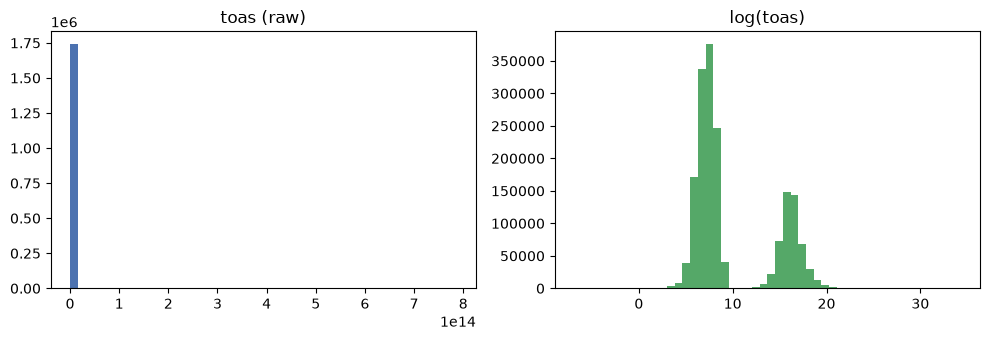

In [46]:
# --- 11.2 Log-transformed size variables ---
df_clean['log_toas'] = np.log(df_clean['toas'])
df_clean['log_empl'] = np.log(df_clean['empl'].fillna(0) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df_clean['toas'].dropna(), bins=50, color='#4C72B0')
axes[0].set_title('toas (raw)')
axes[1].hist(df_clean['log_toas'].dropna(), bins=50, color='#55A868')
axes[1].set_title('log(toas)')
plt.tight_layout()
plt.show()

In [47]:
# --- 11.3 Momentum / history features (lagged within firm, using idnr) ---
df_clean = df_clean.sort_values(['idnr', 'closdate_year'])

df_clean['ncliGrowthThisYear'] = df_clean.groupby('idnr')['ncliGrowthNextYear'].shift(1)

df_clean['toas_growth'] = df_clean.groupby('idnr')['toas'].pct_change()
df_clean['cash_growth'] = df_clean.groupby('idnr')['cash'].pct_change()

# Rolling volatility of the firm's own past outcome (min_periods=2 so it's not NaN after just 1 obs)
df_clean['growth_volatility'] = (
    df_clean.groupby('idnr')['ncliGrowthNextYear']
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=2).std())
)

# Firm age and tenure in the panel
df_clean['firm_age'] = df_clean['closdate_year'] - df_clean['dateinc'].dt.year
df_clean['years_in_panel'] = df_clean.groupby('idnr').cumcount()

df_clean[['idnr', 'closdate_year', 'ncliGrowthThisYear', 'toas_growth',
          'cash_growth', 'growth_volatility', 'firm_age', 'years_in_panel']].head(10)

,idnr,closdate_year,ncliGrowthThisYear,toas_growth,cash_growth,growth_volatility,firm_age,years_in_panel
0,DE2010000001,2013,NaN,NaN,NaN,NaN,36.0,0
1,DE2010000001,2014,-0.034155,-0.002801,0.127094,NaN,37.0,1
2,DE2010000001,2016,-0.832512,-0.075375,-0.493523,0.564524,39.0,2
3,DE2010000001,2017,-0.093514,-0.002093,-0.112008,0.444788,40.0,3
4,DE2010000001,2018,-0.119000,-0.039266,-0.331663,0.419497,41.0,4
5,DE2010000001,2019,0.243604,0.224462,2.062010,0.202394,42.0,5
6,DE2010000001,2020,0.305045,0.222827,0.884569,0.229155,43.0,6
7,DE2010000001,2021,-0.058906,0.034380,1.042699,0.194828,44.0,7
8,DE2010000138,2013,NaN,NaN,NaN,NaN,66.0,0
9,DE2010000138,2014,0.186187,-0.009906,-0.096444,NaN,67.0,1


In [48]:
# --- 11.4 Industry grouping + data-quality flag ---
df_clean['naics_2digit'] = df_clean['naics_core_code'].astype(str).str[:2]
df_clean['is_na_empl'] = df_clean['empl'].isna().astype(int)

print("New feature columns added:")
new_cols = ratio_cols + ['log_toas', 'log_empl', 'ncliGrowthThisYear', 'toas_growth',
                          'cash_growth', 'growth_volatility', 'firm_age', 'years_in_panel',
                          'naics_2digit', 'is_na_empl']
for c in new_cols:
    print(f"  - {c}")

New feature columns added:
  - leverage
  - gearing
  - solvency
  - current_ratio
  - quick_ratio
  - cash_ratio
  - inventory_share
  - receivables_share
  - working_capital_ratio
  - log_toas
  - log_empl
  - ncliGrowthThisYear
  - toas_growth
  - cash_growth
  - growth_volatility
  - firm_age
  - years_in_panel
  - naics_2digit
  - is_na_empl


**Not yet added here** (needs the merged macro/sentiment data, covered in
a later notebook once that join is built):
- `sector_year_growth` (leave-one-out mean growth by industry-year)
- `sentiment_x_leverage`, `sentiment_x_size` (interactions with macro sentiment)

These require the macro/text merge to exist first, so they'll be added once
that pipeline step is in place.